# Quantisation — INT8 Compression for Arduino Nano 33 BLE Sense

Iterative post-training quantisation (PTQ) with finetuning:
1. Profile base float32 models via Edge Impulse
2. PTQ → INT8 TFLite
3. Evaluate accuracy drop; finetune if needed
4. Repeat until accuracy is within 2% macro F1 of float32 baseline
5. Profile final quantised models via Edge Impulse

Run once — operates on whichever `.keras` models exist in `models/`.
Set `REPRESENTATION` to profile/quantise one representation at a time.

In [1]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import f1_score
from pathlib import Path
from dotenv import load_dotenv
import edgeimpulse as ei

load_dotenv('../.env')
ei.API_KEY = os.environ['EI_API_KEY']

REPRESENTATION   = 'mel'    # 'mel' or 'fft'
TARGET_DEVICE    = 'arduino-nano-33-ble'
F1_DROP_LIMIT    = 0.02     # acceptable macro F1 degradation vs float32
MAX_ITERATIONS   = 3        # max PTQ → finetune cycles before giving up
FINETUNE_EPOCHS  = 10
BATCH_SIZE       = 64
N_CALIB          = 200      # calibration samples for PTQ representative dataset
SEED             = 42

DATA_DIR  = Path('../processing') / REPRESENTATION
MODEL_DIR = Path('models')

tf.random.set_seed(SEED)
np.random.seed(SEED)

I0000 00:00:1782373870.636686    3583 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782373870.637191    3583 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1782373871.244069    3583 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782373874.341656    3583 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

## Load data and base models

In [2]:
train = np.load(DATA_DIR / 'train.npz')
test  = np.load(DATA_DIR / 'test.npz')

X_train = train['X'][..., np.newaxis].astype(np.float32)
y_train = train['y_class'].astype(np.int32)
X_test  = test['X'][..., np.newaxis].astype(np.float32)
y_test  = test['y_class'].astype(np.int32)

# Calibration subset from train (normal class only — representative of deployment)
normal_idx = np.where(train['y_binary'] == 0)[0]
rng = np.random.default_rng(SEED)
calib_idx = rng.choice(normal_idx, size=min(N_CALIB, len(normal_idx)), replace=False)
X_calib = X_train[calib_idx]

classifier = keras.models.load_model(MODEL_DIR / f'classifier_{REPRESENTATION}.keras')
autoencoder = keras.models.load_model(MODEL_DIR / f'autoencoder_{REPRESENTATION}.keras')

print('Models loaded.')
print(f'Classifier params:  {classifier.count_params():,}')
print(f'Autoencoder params: {autoencoder.count_params():,}')

E0000 00:00:1782374119.180589    3583 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Models loaded.
Classifier params:  39,204
Autoencoder params: 87,105


## Baseline: float32 accuracy

In [3]:
y_pred_base = classifier.predict(X_test, batch_size=BATCH_SIZE, verbose=0).argmax(axis=1)
f1_base = f1_score(y_test, y_pred_base, average='macro')
print(f'Float32 baseline macro F1: {f1_base:.4f}')

Float32 baseline macro F1: 0.9431


## Profile base models on Arduino Nano 33 BLE Sense

In [9]:
def show_profile(profile, title=''):
    import matplotlib.pyplot as plt

    d      = profile.to_dict()
    info   = d['model']['profileInfo']
    # works for both float32 and int8 models
    target = info.get('int8', info.get('float32'))

    ram_kb = target['memory']['tflite']['ram'] / 1024
    rom_kb = target['memory']['tflite']['rom'] / 1024
    ms     = target['timePerInferenceMs']

    TOTAL_RAM_KB = 256
    TOTAL_ROM_KB = 1024

    fig, axes = plt.subplots(1, 3, figsize=(11, 3))
    fig.suptitle(title or f"Edge Impulse profile — {target.get('device', '')}", fontsize=11)

    for ax, used, total, label, colour in [
        (axes[0], ram_kb, TOTAL_RAM_KB, 'RAM (KB)',        '#4c8eda'),
        (axes[1], rom_kb, TOTAL_ROM_KB, 'ROM / Flash (KB)', '#e07b4c'),
        (axes[2], ms,     50,           'Latency (ms)',     '#6db86d'),
    ]:
        ax.barh(['used', 'budget'], [used, total], color=[colour, '#e0e0e0'])
        ax.set_title(label)
        ax.set_xlim(0, max(total * 1.1, used * 1.1))
        for spine in ['top', 'right']:
            ax.spines[spine].set_visible(False)
        ax.text(used + total * 0.01, 0, f'{used:.1f}', va='center', fontsize=9)
        ax.text(total + total * 0.01, 1, f'{total}', va='center', fontsize=9)
        if used > total:
            ax.axvline(total, color='red', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()

    fits = ram_kb <= TOTAL_RAM_KB and rom_kb <= TOTAL_ROM_KB and ms <= 50
    status = '✓ fits' if fits else '✗ exceeds budget'
    print(f'  RAM: {ram_kb:.1f}/{TOTAL_RAM_KB} KB  |  ROM: {rom_kb:.1f}/{TOTAL_ROM_KB} KB  |  Latency: {ms} ms  |  {status}')

In [4]:
print(f'=== Classifier ({REPRESENTATION}) — float32 ===')
try:
    profile = ei.model.profile(model=classifier, device=TARGET_DEVICE)
    print(profile.summary())
except Exception as e:
    print(f'Could not profile: {e}')

=== Classifier (mel) — float32 ===
INFO:tensorflow:Assets written to: /tmp/tmp_uy_ugad/saved_model/assets


INFO:tensorflow:Assets written to: /tmp/tmp_uy_ugad/saved_model/assets


Saved artifact at '/tmp/tmp_uy_ugad/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  126033554182160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554183696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554183120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554183504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554182352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554183312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554184272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554185232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554184464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554181584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  12603

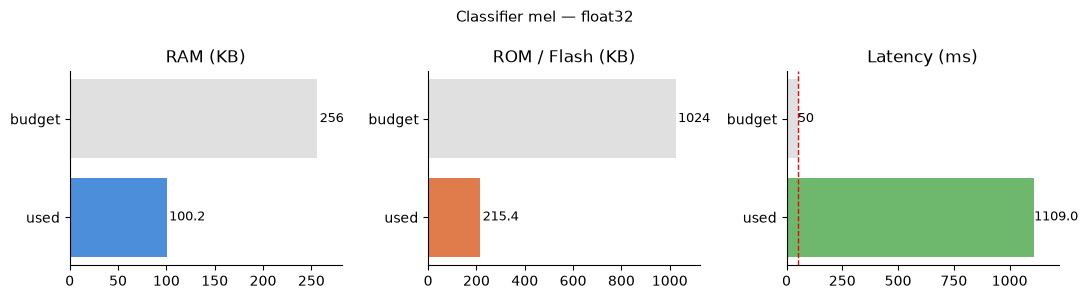

  RAM: 100.2/256 KB  |  ROM: 215.4/1024 KB  |  Latency: 1109 ms  |  ✗ exceeds budget


In [ ]:
show_profile(profile, title=f'Classifier {REPRESENTATION} — float32')

=== Autoencoder (mel) — float32 ===
INFO:tensorflow:Assets written to: /tmp/tmpljyi4iyk/saved_model/assets


INFO:tensorflow:Assets written to: /tmp/tmpljyi4iyk/saved_model/assets


Saved artifact at '/tmp/tmpljyi4iyk/saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name=None)
Captures:
  126033553214736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553215696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553215504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553216080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553215888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553216464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553216272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553216848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553216656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553217232: TensorSpec(shape=(), dtype=tf.resource, name=Non

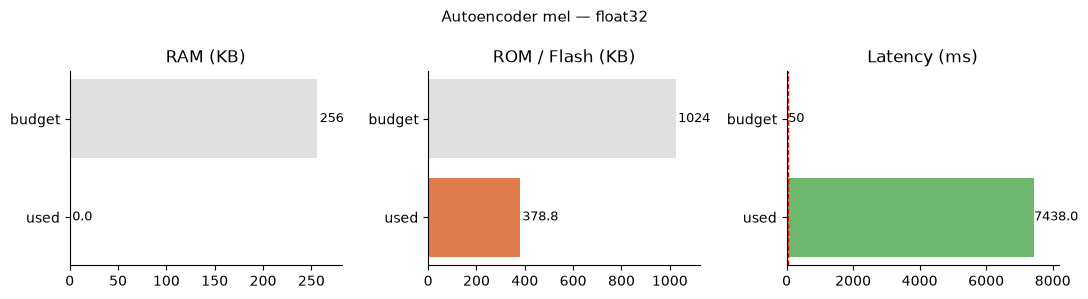

  RAM: 0.0/256 KB  |  ROM: 378.8/1024 KB  |  Latency: 7438 ms  |  ✗ exceeds budget


In [ ]:
print(f'=== Autoencoder ({REPRESENTATION}) — float32 ===')
try:
    profile = ei.model.profile(model=autoencoder, device=TARGET_DEVICE)
    print(profile.summary())
    show_profile(profile, title=f'Autoencoder {REPRESENTATION} — float32')
except Exception as e:
    print(f'Could not profile: {e}')

## PTQ helpers

In [12]:
def representative_dataset(X):
    """Generator yielding calibration batches for TFLite INT8 converter."""
    for i in range(len(X)):
        yield [X[i:i+1]]


def quantise_to_tflite(model, X_calib, out_path):
    """Convert a Keras model to full INT8 TFLite and save to out_path."""
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = lambda: representative_dataset(X_calib)
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type  = tf.int8
    converter.inference_output_type = tf.int8
    tflite_model = converter.convert()
    out_path.write_bytes(tflite_model)
    print(f'Saved {out_path}  ({len(tflite_model)/1024:.1f} KB)')
    return tflite_model


def eval_tflite_classifier(tflite_model, X_test, y_test):
    """Run TFLite classifier on test set and return macro F1."""
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()
    inp = interpreter.get_input_details()[0]
    out = interpreter.get_output_details()[0]

    # INT8 models expect scaled int8 input
    scale, zero_point = inp['quantization']
    X_int8 = (X_test / scale + zero_point).astype(np.int8)

    preds = []
    for i in range(len(X_int8)):
        interpreter.set_tensor(inp['index'], X_int8[i:i+1])
        interpreter.invoke()
        logits = interpreter.get_tensor(out['index'])
        preds.append(logits.argmax())

    return f1_score(y_test, preds, average='macro')

## Iterative PTQ → finetune loop (classifier)

Each iteration:
1. Quantise current model to INT8 TFLite
2. Evaluate macro F1 of quantised model on test set
3. If drop ≤ `F1_DROP_LIMIT` → done
4. Otherwise finetune float32 model for `FINETUNE_EPOCHS` with a lower learning rate, then repeat

In [13]:
current_model = classifier
best_tflite   = None
best_f1_quant = 0.0

for iteration in range(1, MAX_ITERATIONS + 1):
    print(f'\n--- Iteration {iteration} ---')

    out_path   = MODEL_DIR / f'classifier_{REPRESENTATION}_ptq_iter{iteration}.tflite'
    tflite_mdl = quantise_to_tflite(current_model, X_calib, out_path)

    f1_quant = eval_tflite_classifier(tflite_mdl, X_test, y_test)
    drop = f1_base - f1_quant
    print(f'Quantised macro F1: {f1_quant:.4f}  (drop: {drop:.4f})')

    if f1_quant > best_f1_quant:
        best_f1_quant = f1_quant
        best_tflite   = tflite_mdl
        (MODEL_DIR / f'classifier_{REPRESENTATION}_ptq.tflite').write_bytes(best_tflite)

    if drop <= F1_DROP_LIMIT:
        print(f'Acceptable drop — stopping after iteration {iteration}.')
        break

    if iteration < MAX_ITERATIONS:
        print('Drop too large — finetuning float32 model...')
        # Lower LR finetune to recover accuracy lost to quantisation noise
        current_model.compile(
            optimizer=keras.optimizers.Adam(1e-4),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'],
        )
        current_model.fit(
            X_train, y_train,
            epochs=FINETUNE_EPOCHS,
            batch_size=BATCH_SIZE,
            validation_split=0.1,
            verbose=1,
        )
else:
    print(f'Reached max iterations. Best quantised macro F1: {best_f1_quant:.4f}')

print(f'\nFinal best quantised macro F1: {best_f1_quant:.4f}')
print(f'Float32 baseline:              {f1_base:.4f}')
print(f'Drop:                          {f1_base - best_f1_quant:.4f}')


--- Iteration 1 ---
INFO:tensorflow:Assets written to: /tmp/tmpzjq_9muz/assets


INFO:tensorflow:Assets written to: /tmp/tmpzjq_9muz/assets


Saved artifact at '/tmp/tmpzjq_9muz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  126033554182160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554183696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554183120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554183504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554182352: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554183312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554184272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554185232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554184464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554181584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033554182544: 

/home/mdvmlhtr/drone-anomaly/.venv/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1782374771.540148    3583 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782374771.540196    3583 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782374771.540661    3583 reader.cc:83] Reading SavedModel from: /tmp/tmpzjq_9muz
I0000 00:00:1782374771.541391    3583 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782374771.541404    3583 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpzjq_9muz
I0000 00:00:1782374771.547873    3583 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
I0000 00:00:1782374771.549187    3583 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782374771.613277    3583 loader.cc:220] Running initialization op o

Saved models/classifier_mel_ptq_iter1.tflite  (48.2 KB)
Quantised macro F1: 0.9441  (drop: -0.0010)
Acceptable drop — stopping after iteration 1.

Final best quantised macro F1: 0.9441
Float32 baseline:              0.9431
Drop:                          -0.0010


## Profile quantised classifier on Arduino Nano 33 BLE Sense

In [15]:
tflite_path = MODEL_DIR / f'classifier_{REPRESENTATION}_ptq.tflite'
print(f'=== Classifier ({REPRESENTATION}) — INT8 ===')
try:
    profile = ei.model.profile(model=str(tflite_path), device=TARGET_DEVICE)
    print(profile.summary())
except Exception as e:
    print(f'Could not profile: {e}')

=== Classifier (mel) — INT8 ===
Target results for int8:
{
    "variant": "int8",
    "device": "arduino-nano-33-ble",
    "tfliteFileSizeBytes": 49328,
    "isSupportedOnMcu": true,
    "memory": {
        "tflite": {
            "ram": 18379,
            "rom": 101880,
            "arenaSize": 17939
        },
        "eon": {
            "ram": 14320,
            "rom": 76608,
            "arenaSize": 12288
        },
        "eonRamOptimized": {
            "ram": 19520,
            "rom": 85760,
            "arenaSize": 14224
        }
    },
    "timePerInferenceMs": 61,
    "customMetrics": [],
    "hasPerformance": true
}


Performance on device types:
{
    "variant": "int8",
    "lowEndMcu": {
        "description": "Estimate for a Cortex-M0+ or similar, running at 40MHz",
        "timePerInferenceMs": 489,
        "memory": {
            "tflite": {
                "ram": 18187,
                "rom": 90088
            },
            "eon": {
                "ram": 13280,
  

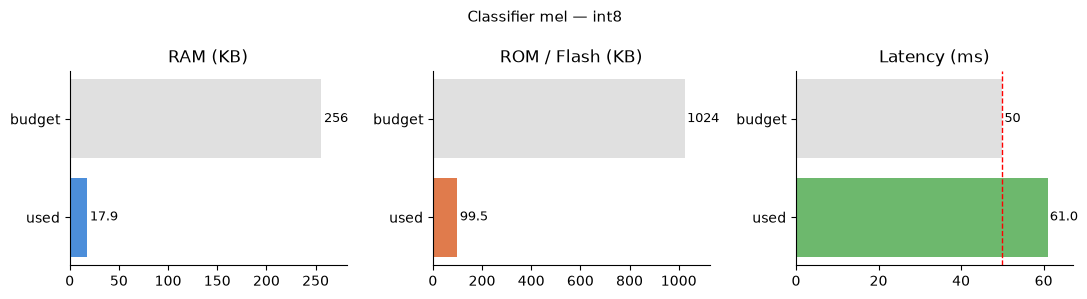

  RAM: 17.9/256 KB  |  ROM: 99.5/1024 KB  |  Latency: 61 ms  |  ✗ exceeds budget


In [16]:
show_profile(profile, title=f'Classifier {REPRESENTATION} — int8')

## Quantise autoencoder (PTQ only — no finetuning loop needed)

The autoencoder uses reconstruction error as its output, not class logits.
We check that mean reconstruction error still separates normal vs. broken
after quantisation rather than computing F1.

In [17]:
ae_tflite_path = MODEL_DIR / f'autoencoder_{REPRESENTATION}_ptq.tflite'
ae_tflite = quantise_to_tflite(autoencoder, X_calib, ae_tflite_path)

# Quick sanity check: reconstruction error separation still holds
threshold = np.load(MODEL_DIR / f'autoencoder_{REPRESENTATION}_threshold.npy')

interpreter = tf.lite.Interpreter(model_content=ae_tflite)
interpreter.allocate_tensors()
inp = interpreter.get_input_details()[0]
out = interpreter.get_output_details()[0]
scale, zero_point = inp['quantization']
X_test_int8 = (X_test / scale + zero_point).astype(np.int8)

errors = []
for i in range(len(X_test_int8)):
    interpreter.set_tensor(inp['index'], X_test_int8[i:i+1])
    interpreter.invoke()
    recon = interpreter.get_tensor(out['index']).astype(np.float32)
    orig  = X_test_int8[i:i+1].astype(np.float32)
    errors.append(np.mean((orig - recon) ** 2))

errors = np.array(errors)
y_test_bin = test['y_binary']
print(f'Normal  error — mean: {errors[y_test_bin==0].mean():.4f}')
print(f'Broken  error — mean: {errors[y_test_bin==1].mean():.4f}')
print('(Broken mean should be noticeably higher than normal mean)')

INFO:tensorflow:Assets written to: /tmp/tmpjbn3cx1b/assets


INFO:tensorflow:Assets written to: /tmp/tmpjbn3cx1b/assets


Saved artifact at '/tmp/tmpjbn3cx1b'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 32, 32, 1), dtype=tf.float32, name=None)
Captures:
  126033553214736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553215696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553215504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553216080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553215888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553216464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553216272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553216848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553216656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  126033553217232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1260335

/home/mdvmlhtr/drone-anomaly/.venv/lib/python3.13/site-packages/tensorflow/lite/python/convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
W0000 00:00:1782376367.139912    3583 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1782376367.139958    3583 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1782376367.140136    3583 reader.cc:83] Reading SavedModel from: /tmp/tmpjbn3cx1b
I0000 00:00:1782376367.141040    3583 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1782376367.141053    3583 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpjbn3cx1b
I0000 00:00:1782376367.153331    3583 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1782376367.202843    3583 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpjbn3cx1b
I0000 00:00:1782376367.219245    3583 loader.cc:471] SavedModel load f

Saved models/autoencoder_mel_ptq.tflite  (122.1 KB)
Normal  error — mean: 480.5897
Broken  error — mean: 526.0738
(Broken mean should be noticeably higher than normal mean)


=== Autoencoder (mel) — INT8 ===
Target results for int8:
{
    "variant": "int8",
    "device": "arduino-nano-33-ble",
    "tfliteFileSizeBytes": 125080,
    "isSupportedOnMcu": false,
    "memory": {
        "tflite": {
            "ram": 0,
            "rom": 125080,
            "arenaSize": 0
        }
    },
    "timePerInferenceMs": 282,
    "mcuSupportError": "Calculated arena size is >6MB",
    "customMetrics": [],
    "hasPerformance": true
}


Performance on device types:
{
    "variant": "int8",
    "lowEndMcu": {
        "description": "Estimate for a Cortex-M0+ or similar, running at 40MHz",
        "timePerInferenceMs": 2285,
        "memory": {},
        "supported": false,
        "mcuSupportError": "Calculated arena size is >6MB"
    },
    "highEndMcu": {
        "description": "Estimate for a Cortex-M7 or other high-end MCU/DSP, running at 240MHz",
        "timePerInferenceMs": 52,
        "memory": {
            "tflite": {
                "ram": 0,
                

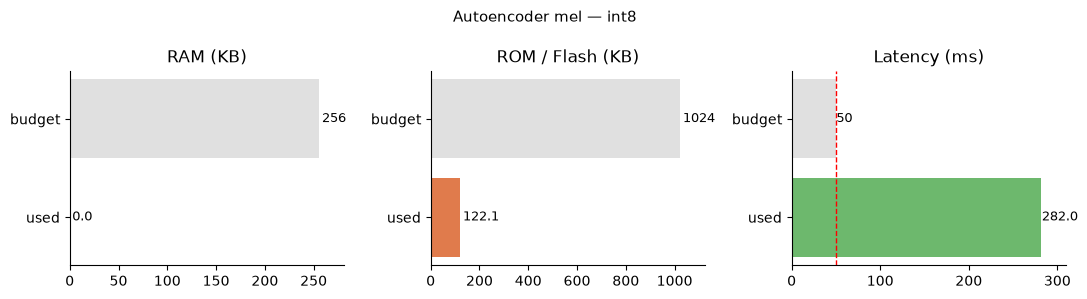

  RAM: 0.0/256 KB  |  ROM: 122.1/1024 KB  |  Latency: 282 ms  |  ✗ exceeds budget


In [19]:
print(f'=== Autoencoder ({REPRESENTATION}) — INT8 ===')
try:
    profile = ei.model.profile(model=str(ae_tflite_path), device=TARGET_DEVICE)
    print(profile.summary())
    show_profile(profile, title=f'Autoencoder {REPRESENTATION} — int8')
except Exception as e:
    print(f'Could not profile: {e}')